In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect, text

In [2]:
# Relative path of db
db_path = Path.cwd().parent / "data" / "gas_monitoring.db"

In [3]:
# Convert full path to a string
engine = create_engine(f"sqlite:///{db_path.resolve()}")

In [4]:
# Check if successful
inspector = inspect(engine)
# Assuming only 1 table
if len(inspector.get_table_names()) == 1:
    print("Table found:", inspector.get_table_names()[0])
    table_name = inspector.get_table_names()[0]
else:
    print("Multiple tables found")

Table found: gas_monitoring


In [5]:
# Check amount of rows in database
with engine.connect() as connection:
    query = text(f"SELECT COUNT(*) FROM {table_name};")
    db_rows = connection.execute(query).scalar()

print(f" Total rows: {db_rows:,}")

 Total rows: 10,000


In [6]:
# Pull table
df = pd.read_sql_table(table_name, engine)
print(f"Loaded {len(df)} rows into memory.")

Loaded 10000 rows into memory.


In [7]:
df.head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

In [10]:
# number of empty cells per column
df.isnull().sum()

Time of Day                     0
Temperature                     0
Humidity                     1928
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1410
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  834
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1054
Activity Level                  0
dtype: int64

Empty cells are in 4 columns: humidity, metal oxide sensor 2, co gas sensor, and ambient light level

In [11]:
df[df['Humidity'].isna()]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
15,morning,18.53,NaN,80.148375,590.702934,596.654594,765.694890,750.303681,700.075087,0.0,1903,heating_active,very_bright,Low Activity
25,afternoon,19.46,NaN,81.850351,616.549883,538.974555,764.222091,488.808765,625.088579,1.0,7241,maintenance_mode,very_dim,Low Activity
30,afternoon,20.52,NaN,88.131804,614.973747,506.676587,755.728581,689.985534,611.737822,NaN,7241,cooling_active,bright,Moderate Activity
36,afternoon,20.68,NaN,82.119635,618.282123,428.657481,764.534299,718.546551,637.902211,1.0,7241,cooling_active,very_bright,Moderate Activity
38,morning,19.64,NaN,139.902168,579.301906,476.971294,720.978887,682.696743,607.577312,1.0,4507,off,dim,Moderate Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9971,afternoon,17.31,NaN,94.323686,594.188754,461.426538,726.681435,693.159035,628.618046,2.0,2679,cooling_active,None,Moderate Activity
9979,night,21.33,NaN,134.623928,553.641599,414.279896,694.386273,651.722779,572.288211,2.0,4761,eco_mode,None,Low Activity
9993,morning,16.84,NaN,121.589332,589.097836,502.213084,762.497500,562.849426,669.410300,0.0,5820,eco_mode,bright,Low Activity
9995,evening,23.45,NaN,137.854649,544.124855,510.926349,NaN,680.916215,620.292682,1.0,2586,maintenance_mode,very_bright,Low Activity


In [12]:
df[df['MetalOxideSensor_Unit2'].isna()]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
12,morning,17.79,51.15,116.555038,590.747488,456.426736,NaN,691.308364,609.604835,1.0,3418,ventilation_only,None,Moderate Activity
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,Moderate Activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,NaN,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,Low Activity
35,evening,24.02,48.39,128.692361,539.592438,386.797276,NaN,543.856834,477.859881,4.0,7058,maintenance_mode,bright,Low Activity
49,afternoon,22.99,51.07,116.780904,532.683719,402.180211,NaN,615.559061,534.378179,4.0,4703,COOLING_ACTIVE,bright,Low Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,Low_Activity
9977,evening,22.85,46.80,119.371474,586.565204,422.759013,NaN,673.232204,625.357845,2.0,9658,maintenance_mode,very_bright,High Activity
9983,afternoon,23.00,152.46,116.846743,577.424852,460.276579,NaN,675.221322,601.178927,1.0,4507,maintenance_mode,moderate,High Activity
9992,evening,22.92,46.64,119.253573,550.549792,495.301121,NaN,685.680572,619.343335,1.0,2586,heating_active,bright,High Activity


In [13]:
df[df['CO_GasSensor'].isna()]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,Low Activity
19,afternoon,19.57,51.23,91.168499,611.561714,537.713012,751.668484,709.823944,621.493028,NaN,7241,maintenance_mode,very_bright,Moderate Activity
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,Moderate Activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,NaN,3856,ventilation_only,very_bright,Moderate Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9954,afternoon,293.94,44.55,75.618247,567.044186,511.008803,753.665230,718.474331,664.598081,NaN,2586,eco_mode,very_bright,Moderate Activity
9964,afternoon,21.69,44.71,81.385283,561.968352,527.330609,752.324424,718.379962,659.181524,NaN,2586,Heating_Active,very_dim,Low Activity
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,Low_Activity
9980,night,292.01,52.10,118.519591,587.887196,464.160197,748.870053,712.972441,642.839403,NaN,9658,off,very_bright,ModerateActivity


In [14]:
df[df['Ambient Light Level'].isna()]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,Low Activity
11,afternoon,19.71,48.68,80.161332,615.972458,575.491588,780.078308,732.349009,667.927995,0.0,7241,eco_mode,None,ModerateActivity
12,morning,17.79,51.15,116.555038,590.747488,456.426736,NaN,691.308364,609.604835,1.0,3418,ventilation_only,None,Moderate Activity
17,afternoon,19.73,50.62,91.736107,619.342912,527.869881,761.418621,703.674613,618.386499,0.0,7241,Heating_active,None,High Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,Low_Activity
9971,afternoon,17.31,NaN,94.323686,594.188754,461.426538,726.681435,693.159035,628.618046,2.0,2679,cooling_active,None,Moderate Activity
9976,night,20.99,57.61,-9.992761,561.460188,446.620844,703.945003,663.041519,578.163559,1.0,4761,Maintenance_mode,None,Low Activity
9979,night,21.33,NaN,134.623928,553.641599,414.279896,694.386273,651.722779,572.288211,2.0,4761,eco_mode,None,Low Activity


In [15]:
# number of duplicate rows
df.duplicated().sum()

171

In [16]:
# inspect duplicate rows
df[df.duplicated()]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
493,evening,23.52,43.25,88.690954,603.702902,496.306607,747.498224,702.297867,630.522057,1.0,5693,heating_active,bright,Moderate Activity
1097,morning,18.99,55.92,118.637160,600.695160,502.885955,735.720000,703.310462,615.349296,1.0,5693,ventilation_only,bright,High Activity
1252,evening,24.06,44.04,105.264563,598.388502,496.349041,735.360708,703.337182,629.341589,1.0,8374,off,moderate,Moderate Activity
1491,morning,17.37,44.26,60.765226,621.136492,602.596911,800.021351,754.924569,722.835228,0.0,5693,off,moderate,Moderate Activity
1576,night,20.77,NaN,105.027749,600.128419,469.521450,738.124661,686.433295,612.079199,2.0,8374,ventilation_only,bright,Moderate Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9784,morning,19.56,46.23,82.165104,618.878313,547.258686,774.347295,746.520275,688.083021,0.0,5693,maintenance_mode,bright,Low Activity
9812,afternoon,19.45,53.78,127.170465,568.974112,416.661925,718.673151,686.167655,621.327160,1.0,3074,ventilation_only,very_bright,High Activity
9902,night,18.08,54.39,118.473630,587.984997,506.368702,739.635625,698.921105,617.032041,1.0,9658,cooling_active,moderate,Low Activity
9946,evening,25.70,48.15,121.606097,539.641062,484.896859,675.467858,594.954642,537.075883,2.0,6817,maintenance_mode,moderate,Moderate Activity


In [17]:
# remove duplicate rows without creating new df
df.drop_duplicates(inplace=True)
df.shape

(9829, 14)

In [18]:
# values in time of day column
df["Time of Day"].unique()

array(['morning', 'afternoon', 'night', 'evening'], dtype=object)

In [19]:
# range of temperature readings (celsius)
df["Temperature"].describe()

count    9829.000000
mean       42.618136
std        74.559993
min         6.903485
25%        18.930000
50%        20.510000
75%        23.180000
max       307.070000
Name: Temperature, dtype: float64

min and max values are abnormal

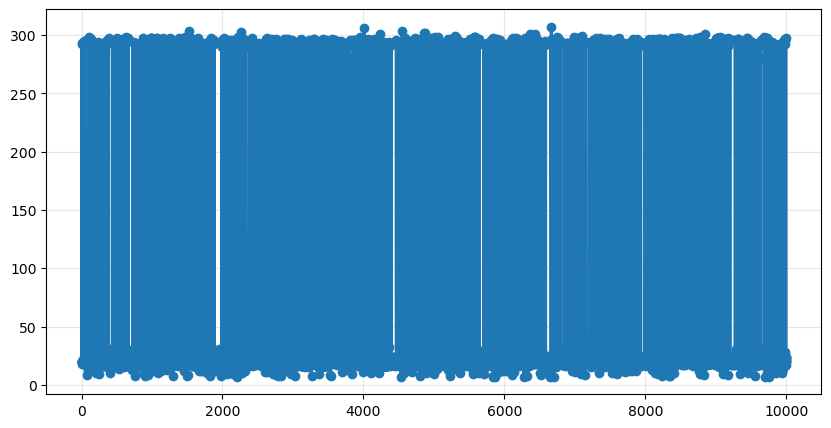

In [20]:
# visualise temperature values
plt.figure(figsize=(10, 5))
plt.plot(df["Temperature"], linewidth=2, marker='o')

plt.grid(True, alpha=0.3)
plt.show()

In [21]:
# Finding where the abnormally high readings start
print((df["Temperature"] > 30).sum())
print((df["Temperature"] > 40).sum())
print((df["Temperature"] > 50).sum())

862
795
795


In [22]:
print((df["Temperature"] > 35).sum())
print((df["Temperature"] > 34).sum())
print((df["Temperature"] > 33).sum())

795
801
817


In [23]:
# inspect abnormally high values
df[df["Temperature"] > 35]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
8,afternoon,292.59,47.92,74.100322,624.577270,564.745091,798.290403,753.467986,674.278245,0.0,7241,maintenance_mode,very_bright,Low Activity
24,afternoon,292.65,51.95,84.581085,617.316915,534.905951,767.204960,717.770588,617.513808,1.0,7241,eco_mode,very_bright,Moderate Activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,NaN,3856,ventilation_only,very_bright,Moderate Activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,NaN,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,Low Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9980,night,292.01,52.10,118.519591,587.887196,464.160197,748.870053,712.972441,642.839403,NaN,9658,off,very_bright,ModerateActivity
9981,evening,295.61,45.84,85.732048,559.357007,511.585673,749.994773,704.264333,647.845091,1.0,2586,eco_mode,moderate,Moderate Activity
9982,evening,295.67,45.89,91.771848,552.961200,515.944782,751.423006,713.109219,653.457688,1.0,2586,maintenance_mode,very_dim,High Activity
9989,night,296.17,49.35,119.874350,571.897844,413.811232,711.960225,673.048526,589.516066,2.0,1826,ventilation_only,None,Low Activity


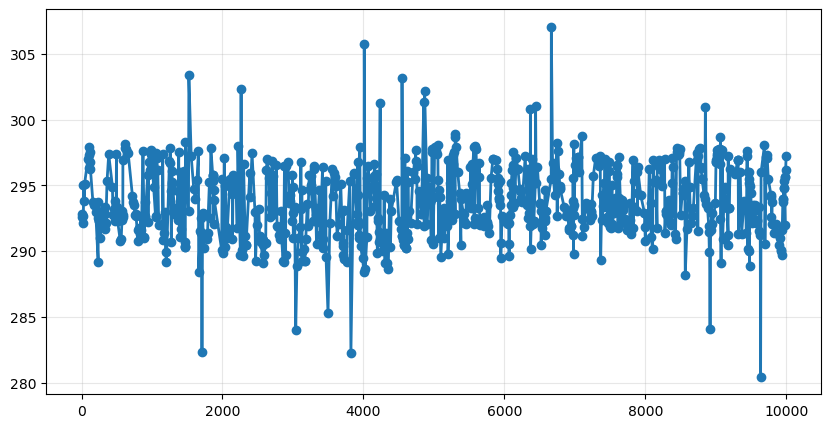

In [24]:
# visualise temperature above 35
plt.figure(figsize=(10, 5))
plt.plot((df[df["Temperature"] > 35])["Temperature"], linewidth=2, marker='o')

plt.grid(True, alpha=0.3)
plt.show()

Assuming that the abnormally high temperature values are 10x what they should be

In [25]:
# divide all temperatures above 35 by 10
df.loc[df['Temperature'] > 35, 'Temperature'] /= 10

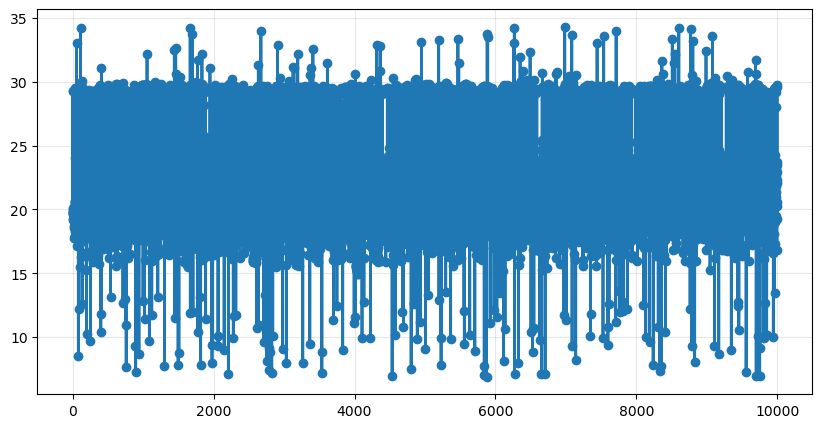

In [26]:
# visualise updated temperature readings
plt.figure(figsize=(10, 5))
plt.plot(df["Temperature"], linewidth=2, marker='o')

plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# inspect low temperature values
df[df["Temperature"] < 15]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
80,evening,8.499293,51.84,104.237654,609.733706,473.936972,NaN,676.306256,608.415572,1.0,7241,heating_active,bright,Low Activity
89,night,12.229653,47.32,111.790594,577.632466,444.180853,723.045899,696.629900,611.205888,2.0,6431,heating_active,very_bright,Low Activity
137,night,12.614772,52.79,115.635688,550.871360,471.867654,697.028391,636.657652,571.409105,1.0,6817,off,bright,Low Activity
198,night,10.233207,56.94,111.733666,591.270244,458.709013,728.708661,859.125193,612.345406,3.0,7241,heating_active,None,Low Activity
252,morning,9.691520,48.13,81.914994,612.981958,545.951108,768.793812,745.684560,664.890366,2.0,3856,ventilation_only,very_bright,Moderate Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9804,night,9.902174,NaN,93.863652,559.891665,489.564057,749.978097,542.993713,632.326626,1.0,9241,ventilation_only,very_bright,High Activity
9826,morning,12.702877,50.07,62.835035,614.971921,586.409119,781.033651,751.944760,693.920387,NaN,4129,eco_mode,moderate,Moderate Activity
9849,evening,10.152654,47.09,113.662748,586.588217,425.938439,743.931645,699.069839,636.930028,1.0,5820,off,very_dim,Moderate Activity
9943,afternoon,10.032879,44.70,64.945329,572.230665,547.016366,781.940559,563.421191,698.455061,0.0,2586,heating_active,very_bright,Moderate Activity


decide what to do with low temperature readings